
# Module 2C — Pooled Monte Carlo test predictions: global predicted-DGE landscape

This notebook pools all five Monte Carlo random-split test prediction sets into one analysis.

Design:
- repeated underlying biological profiles across folds are kept;
- repetition is tracked and summarized, not deduplicated;
- one global top-10 cell set is defined from pooled test metadata;
- only perturbations mapping to exactly one clear broad MoA family are retained;
- `Unannotated`, `Multi-mechanism`, and `Other annotated` are excluded;
- no fold-specific normalization or harmonization is applied;
- predicted DGE = predicted perturbed expression − matched baseline expression;
- one global PCA retains at least 80% variance;
- one global 2D UMAP is reused for:
  - A. Broad MoA
  - B. Cell line
  - C. Duration
  - D. Dose
  - E. Source fold/model diagnostic

Outputs:
`.../analysis/DGEStructureAnalysis/Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE/`


## This improved version additionally includes
- reduced point size and opacity for dense pooled plots;
- full-range A–D and fold-diagnostic figures with improved readability;
- quantitative kNN fold-mixing statistics, including the expected different-fold fraction under random mixing;
- a fold-mixing summary plot.


In [ ]:

# 0. Configuration
from pathlib import Path

MAIN_DIR = Path(
    "~/DEPICT/Code/downstream_analysis_code/DGElandscape"
)
ANALYSIS_DIR = MAIN_DIR / "analysis"
EMBEDDING_DIR = MAIN_DIR / "analysis" / "resp_latents_random_split"
OUT_ROOT = ANALYSIS_DIR / "Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

DRUG_REPUR_PATH = MAIN_DIR / "Data" / "repurposing_drugs_20200324.txt"

RANDOM_SPLITS = [f"random_split{i}" for i in range(1, 6)]
PARTITION = "test"
TOP_N_CELLS = 10

PCA_VARIANCE_TARGET = 0.80
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.25
UMAP_METRIC = "cosine"
RANDOM_SEED = 20260706

MIN_UNIQUE_DRUGS_PER_MOA = 10
MIN_PROFILES_PER_MOA = 100

CATEGORICAL_POINT_ALPHA = 0.52
CATEGORICAL_POINT_SIZE = 0.95
DOSE_POINT_ALPHA = 0.50
DOSE_POINT_SIZE = 0.90

print("Output root:", OUT_ROOT)

K_MIX = 30


Output root: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DGEStructureAnalysis/Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE


In [2]:

# 1. Imports and fixed palettes
import gc
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import umap.umap_ as umap

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 9,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

MOA_COLOR_MAP = {
    "RTK / tyrosine kinase signaling": "#1f77b4",
    "PI3K–AKT–mTOR signaling": "#d62728",
    "MAPK signaling": "#ff7f0e",
    "Cell cycle / mitosis": "#9467bd",
    "DNA damage / replication / repair": "#8c564b",
    "Microtubule / cytoskeleton": "#e377c2",
    "Epigenetic / chromatin regulation": "#2ca02c",
    "Protein homeostasis / stress response": "#17becf",
    "Immune / inflammatory signaling": "#bcbd22",
    "GPCR / neurotransmitter signaling": "#7f7f7f",
    "Ion channels / transport": "#393b79",
    "Metabolic / endocrine / nuclear receptor": "#637939",
}

CELL_COLOR_MAP = {
    "MCF7": "#1f77b4",
    "VCAP": "#ff7f0e",
    "PC3": "#2ca02c",
    "A375": "#d62728",
    "HT29": "#9467bd",
    "A549": "#8c564b",
    "HA1E": "#e377c2",
    "HCC515": "#7f7f7f",
    "HEPG2": "#bcbd22",
    "NPC": "#17becf",
}

DURATION_COLOR_MAP = {
    "3.0": "#9467bd",
    "6.0": "#1f77b4",
    "24.0": "#ff7f0e",
    "48.0": "#d62728",
}

FOLD_COLOR_MAP = {
    "random_split1": "#1f77b4",
    "random_split2": "#ff7f0e",
    "random_split3": "#2ca02c",
    "random_split4": "#d62728",
    "random_split5": "#9467bd",
}

MOA_ORDER = list(MOA_COLOR_MAP.keys())


In [3]:

# 2. Drug Repurposing Hub metadata
drug_repur = pd.read_csv(DRUG_REPUR_PATH, sep="\t", skiprows=9)

required_cols = {"pert_iname", "moa"}
missing = required_cols - set(drug_repur.columns)
if missing:
    raise KeyError(f"Missing Drug Repurposing Hub columns: {sorted(missing)}")

drug_repur["pert_iname_norm"] = (
    drug_repur["pert_iname"].astype(str).str.strip().str.lower()
)

def combine_unique_moa(values):
    vals = []
    for v in values:
        if pd.isna(v):
            continue
        s = str(v).strip()
        if s and s.lower() != "nan":
            vals.append(s)
    vals = list(dict.fromkeys(vals))
    return "|".join(vals) if vals else np.nan

drug_moa = (
    drug_repur.groupby("pert_iname_norm", as_index=False)
    .agg(
        pert_iname=("pert_iname", "first"),
        moa=("moa", combine_unique_moa),
    )
)

print("Drug metadata rows:", len(drug_repur))
print("Unique normalized drug names:", drug_moa["pert_iname_norm"].nunique())


Drug metadata rows: 6798
Unique normalized drug names: 6798


In [4]:

# 3. Broad MoA mapping
BROAD_MOA_PATTERNS = {
    "RTK / tyrosine kinase signaling": [
        r"\begfr\b", r"\berbb\b", r"\bvegfr\b", r"\bfgfr\b", r"\bpdgfr\b",
        r"\balk\b", r"\bmet\b", r"\bc-?met\b", r"\bret\b", r"\bkit\b",
        r"\bflt3\b", r"\bflt1\b", r"\bflt4\b", r"\bkdr\b",
        r"\bbcr[- ]?abl\b", r"\babl kinase\b", r"\bsrc inhibitor\b",
        r"\btyrosine kinase inhibitor\b", r"\bprotein tyrosine kinase inhibitor\b",
        r"\baxl\b", r"\blyn tyrosine kinase\b",
    ],
    "PI3K–AKT–mTOR signaling": [
        r"\bpi3k\b", r"\bphosphoinositide 3[- ]kinase\b",
        r"\bakt inhibitor\b", r"\bmtor inhibitor\b",
    ],
    "MAPK signaling": [
        r"\braf inhibitor\b", r"\bbraf\b", r"\bmek inhibitor\b",
        r"\bmap kinase inhibitor\b", r"\bmapk inhibitor\b",
        r"\bp38 mapk inhibitor\b", r"\berk inhibitor\b",
    ],
    "Cell cycle / mitosis": [
        r"\bcdk inhibitor\b", r"\bcyclin[- ]dependent kinase inhibitor\b",
        r"\baurora kinase inhibitor\b", r"\bplk inhibitor\b",
        r"\bpolo[- ]like kinase inhibitor\b", r"\bcell cycle inhibitor\b",
        r"\bwee1 inhibitor\b",
    ],
    "DNA damage / replication / repair": [
        r"\btopoisomerase inhibitor\b", r"\bparp inhibitor\b",
        r"\batm kinase inhibitor\b", r"\batr kinase inhibitor\b",
        r"\bdna protein kinase inhibitor\b", r"\bdna[- ]pk inhibitor\b",
        r"\bdna synthesis inhibitor\b", r"\bdna inhibitor\b",
        r"\bdna alkylating agent\b", r"\bdna polymerase inhibitor\b",
        r"\bribonucleotide reductase inhibitor\b",
        r"\bthymidylate synthase inhibitor\b",
        r"\bdna damage\b", r"\bdna repair\b",
    ],
    "Microtubule / cytoskeleton": [
        r"\bmicrotubule inhibitor\b", r"\bmicrotubule stimulant\b",
        r"\btubulin polymerization inhibitor\b", r"\btubulin inhibitor\b",
        r"\bmicrotubule stabil", r"\brho associated kinase inhibitor\b",
        r"\brock inhibitor\b",
    ],
    "Epigenetic / chromatin regulation": [
        r"\bhdac inhibitor\b", r"\bhistone deacetylase inhibitor\b",
        r"\bbromodomain inhibitor\b",
        r"\bhistone lysine methyltransferase inhibitor\b",
        r"\bhistone methyltransferase inhibitor\b",
        r"\bhistone acetyltransferase inhibitor\b",
        r"\bdna methyltransferase inhibitor\b", r"\bdnmt inhibitor\b",
        r"\bepigenetic\b",
    ],
    "Protein homeostasis / stress response": [
        r"\bproteasome inhibitor\b", r"\bhsp inhibitor\b",
        r"\bheat shock protein inhibitor\b", r"\bprotein synthesis inhibitor\b",
        r"\bunfolded protein response\b",
    ],
    "Immune / inflammatory signaling": [
        r"\bjak inhibitor\b", r"\bstat inhibitor\b",
        r"\bnfkb pathway inhibitor\b", r"\bnf-?κb\b",
        r"\btgf beta receptor inhibitor\b", r"\btgf[- ]?beta\b",
        r"\bchemokine receptor antagonist\b", r"\bcc chemokine receptor\b",
        r"\banti-inflammatory agent\b", r"\binterleukin\b", r"\bcytokine\b",
    ],
    "GPCR / neurotransmitter signaling": [
        r"\bdopamine receptor\b", r"\bserotonin receptor\b",
        r"\badrenergic receptor\b", r"\bhistamine receptor\b",
        r"\bacetylcholine receptor\b", r"\bcholinergic receptor\b",
        r"\bopioid receptor\b", r"\bgaba receptor\b",
        r"\bglutamate receptor\b", r"\badenosine receptor\b",
        r"\bpurinergic receptor\b", r"\btachykinin\b",
        r"\bprostanoid receptor\b", r"\bmelatonin receptor\b",
        r"\bcannabinoid receptor\b", r"\bbenzodiazepine receptor\b",
    ],
    "Ion channels / transport": [
        r"\bcalcium channel\b", r"\bsodium channel\b",
        r"\bpotassium channel\b", r"\btrp[vma]\b",
        r"\btransient receptor potential channel\b",
        r"\bion channel\b", r"\bchannel blocker\b", r"\bchannel agonist\b",
    ],
    "Metabolic / endocrine / nuclear receptor": [
        r"\bppar receptor\b", r"\bglucocorticoid receptor\b",
        r"\bestrogen receptor\b", r"\bandrogen receptor\b",
        r"\bprogesterone receptor\b", r"\bretinoid receptor\b",
        r"\bfxr agonist\b", r"\bmineralocorticoid receptor\b",
        r"\bhmgcr inhibitor\b", r"\bcholesterol\b", r"\binsulin sensitizer\b",
    ],
}

BROAD_MOA_REGEX = {
    family: [re.compile(p, flags=re.IGNORECASE) for p in patterns]
    for family, patterns in BROAD_MOA_PATTERNS.items()
}

def map_raw_moa_to_broad(raw_moa):
    if pd.isna(raw_moa) or not str(raw_moa).strip():
        return "Unannotated"

    tokens = [t.strip() for t in str(raw_moa).split("|") if t.strip()]
    matched = set()

    for token in tokens:
        for family, regexes in BROAD_MOA_REGEX.items():
            if any(rx.search(token) for rx in regexes):
                matched.add(family)

    if len(matched) == 0:
        return "Other annotated"
    if len(matched) == 1:
        return next(iter(matched))
    return "Multi-mechanism"

drug_moa["broad_moa_initial"] = drug_moa["moa"].apply(map_raw_moa_to_broad)
print(drug_moa["broad_moa_initial"].value_counts().to_string())


broad_moa_initial
Other annotated                             3263
GPCR / neurotransmitter signaling           1254
Unannotated                                  566
Metabolic / endocrine / nuclear receptor     287
Ion channels / transport                     263
RTK / tyrosine kinase signaling              232
DNA damage / replication / repair            206
Immune / inflammatory signaling              171
Epigenetic / chromatin regulation            110
PI3K–AKT–mTOR signaling                      106
MAPK signaling                                85
Cell cycle / mitosis                          80
Protein homeostasis / stress response         74
Microtubule / cytoskeleton                    65
Multi-mechanism                               36


In [5]:

# 4. Load all fold metadata and define ONE global top-10 cell set
fold_metadata = {}

for split_name in RANDOM_SPLITS:
    prefix = f"{split_name}_{PARTITION}"
    meta_path = EMBEDDING_DIR / f"{prefix}_prediction_metadata.parquet"

    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {meta_path}")

    meta = pd.read_parquet(meta_path).reset_index(drop=True)

    required = ["cell_id", "pert_iname", "dose", "pert_time"]
    missing = [c for c in required if c not in meta.columns]
    if missing:
        raise KeyError(f"{prefix}: missing metadata columns: {missing}")

    meta["cell_id"] = meta["cell_id"].astype(str)
    meta["source_fold"] = split_name
    meta["row_within_fold"] = np.arange(len(meta), dtype=np.int64)

    fold_metadata[split_name] = meta

pooled_meta_all = pd.concat(
    [fold_metadata[s] for s in RANDOM_SPLITS],
    ignore_index=True,
)

global_cell_counts = (
    pooled_meta_all["cell_id"]
    .value_counts()
    .rename_axis("cell_id")
    .reset_index(name="n_pooled_test_rows")
)

GLOBAL_TOP10_CELLS = global_cell_counts.head(TOP_N_CELLS)["cell_id"].tolist()

print("Global top 10 cells:")
print(global_cell_counts.head(TOP_N_CELLS).to_string(index=False))

global_cell_counts.to_csv(
    OUT_ROOT / "global_cell_counts_all_pooled_test_rows.csv",
    index=False,
)


Global top 10 cells:
cell_id  n_pooled_test_rows
   MCF7               59447
   VCAP               54706
    PC3               54205
   A375               35173
   HT29               34672
   A549               31339
   HA1E               24609
 HCC515               15036
  HEPG2               10865
    NPC                8069


In [6]:

# 5. Stable underlying-profile ID for repetition tracking
def choose_profile_id_columns(meta):
    # Prefer a stable explicit identifier if available.
    for c in ["obs_name", "adata_index", "profile_id", "sig_id"]:
        if c in meta.columns:
            return [c]

    # Otherwise build a composite key.
    fallback = [
        c for c in [
            "cell_id",
            "plate",
            "pert_iname",
            "dose",
            "pert_time",
            "paired_control_index",
            "paired_control_adata_index",
        ]
        if c in meta.columns
    ]

    if len(fallback) < 4:
        raise RuntimeError(
            "Could not construct a sufficiently specific profile ID. "
            f"Available columns: {meta.columns.tolist()}"
        )
    return fallback

PROFILE_ID_COLUMNS = choose_profile_id_columns(pooled_meta_all)

def make_profile_id(df):
    return df[PROFILE_ID_COLUMNS].astype(str).agg("||".join, axis=1)

pooled_meta_all["underlying_profile_id"] = make_profile_id(pooled_meta_all)

print("Profile ID columns used:", PROFILE_ID_COLUMNS)
print("Total pooled test rows:", len(pooled_meta_all))
print("Unique underlying profile IDs:", pooled_meta_all["underlying_profile_id"].nunique())


Profile ID columns used: ['obs_name']
Total pooled test rows: 418325
Unique underlying profile IDs: 342568


In [7]:

# 6. Track repetition before filtering
profile_fold_counts = (
    pooled_meta_all.groupby("underlying_profile_id")
    .agg(
        n_occurrences=("source_fold", "size"),
        n_distinct_folds=("source_fold", "nunique"),
    )
    .reset_index()
)

repetition_distribution = (
    profile_fold_counts["n_distinct_folds"]
    .value_counts()
    .sort_index()
    .rename_axis("n_distinct_folds")
    .reset_index(name="n_underlying_profiles")
)

repetition_distribution["fraction_underlying_profiles"] = (
    repetition_distribution["n_underlying_profiles"]
    / repetition_distribution["n_underlying_profiles"].sum()
)

profile_fold_counts.to_parquet(
    OUT_ROOT / "underlying_profile_fold_counts_all_pooled_test_rows.parquet",
    index=False,
)
repetition_distribution.to_csv(
    OUT_ROOT / "underlying_profile_repetition_distribution_all_pooled_test_rows.csv",
    index=False,
)

print(repetition_distribution.to_string(index=False))


 n_distinct_folds  n_underlying_profiles  fraction_underlying_profiles
                1                 274384                      0.800962
                2                  61028                      0.178149
                3                   6751                      0.019707
                4                    393                      0.001147
                5                     12                      0.000035


In [8]:

# 7. Build pooled predicted DGE using the global top-10 cells
pooled_meta_parts = []
pooled_dge_parts = []

for split_name in RANDOM_SPLITS:
    print("\nLoading", split_name)

    prefix = f"{split_name}_{PARTITION}"
    meta = fold_metadata[split_name].copy()

    baseline_path = EMBEDDING_DIR / f"{prefix}_matched_baseline_expression_978_float32.npy"
    pred_path = EMBEDDING_DIR / f"{prefix}_predicted_perturbed_expression_logits_978_float32.npy"

    for p in [baseline_path, pred_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing required file: {p}")

    baseline = np.load(baseline_path, mmap_mode="r")
    pred = np.load(pred_path, mmap_mode="r")

    if baseline.shape != pred.shape or baseline.shape[0] != len(meta):
        raise RuntimeError(
            f"{prefix}: array/metadata alignment mismatch. "
            f"baseline={baseline.shape}, pred={pred.shape}, metadata={len(meta)}"
        )

    mask = meta["cell_id"].isin(GLOBAL_TOP10_CELLS).to_numpy()
    rows = np.flatnonzero(mask)

    meta_sub = meta.loc[mask].reset_index(drop=True)
    pred_dge_sub = np.asarray(pred[rows] - baseline[rows], dtype=np.float32)

    meta_sub["pert_iname_norm"] = (
        meta_sub["pert_iname"].astype(str).str.strip().str.lower()
    )
    meta_sub = meta_sub.merge(
        drug_moa[["pert_iname_norm", "moa", "broad_moa_initial"]],
        on="pert_iname_norm",
        how="left",
        validate="m:1",
    )
    meta_sub["broad_moa_initial"] = meta_sub["broad_moa_initial"].fillna("Unannotated")
    meta_sub["underlying_profile_id"] = make_profile_id(meta_sub)

    pooled_meta_parts.append(meta_sub)
    pooled_dge_parts.append(pred_dge_sub)

pooled_meta_top10 = pd.concat(pooled_meta_parts, ignore_index=True)
pooled_pred_dge_top10 = np.concatenate(pooled_dge_parts, axis=0)

if len(pooled_meta_top10) != pooled_pred_dge_top10.shape[0]:
    raise RuntimeError("Pooled metadata and pooled DGE row counts do not match.")

print("Pooled global-top10 rows:", len(pooled_meta_top10))
print("Pooled DGE shape:", pooled_pred_dge_top10.shape)

del pooled_dge_parts
gc.collect()



Loading random_split1

Loading random_split2

Loading random_split3

Loading random_split4

Loading random_split5
Pooled global-top10 rows: 328121
Pooled DGE shape: (328121, 978)


10201

In [9]:

# 8. Clean single-family MoA filtering and support thresholds
filtering_summary = {
    "pooled_top10_rows_before_moa_filter": len(pooled_meta_top10),
    "pooled_top10_unique_drugs_before_moa_filter": pooled_meta_top10["pert_iname_norm"].nunique(),
    "unannotated_rows": int((pooled_meta_top10["broad_moa_initial"] == "Unannotated").sum()),
    "multi_mechanism_rows": int((pooled_meta_top10["broad_moa_initial"] == "Multi-mechanism").sum()),
    "other_annotated_rows": int((pooled_meta_top10["broad_moa_initial"] == "Other annotated").sum()),
}

clean_mask = ~pooled_meta_top10["broad_moa_initial"].isin(
    ["Unannotated", "Multi-mechanism", "Other annotated"]
)

clean_meta = pooled_meta_top10.loc[clean_mask].reset_index(drop=True)
clean_dge = pooled_pred_dge_top10[np.flatnonzero(clean_mask.to_numpy())]

support = (
    clean_meta.groupby("broad_moa_initial", as_index=False)
    .agg(
        n_unique_drugs=("pert_iname_norm", "nunique"),
        n_profiles=("pert_iname_norm", "size"),
        n_cells=("cell_id", "nunique"),
        n_folds=("source_fold", "nunique"),
        n_dose_values=("dose", "nunique"),
        n_time_values=("pert_time", "nunique"),
    )
    .sort_values(["n_profiles", "n_unique_drugs"], ascending=False)
)

retained_families = set(
    support.loc[
        (support["n_unique_drugs"] >= MIN_UNIQUE_DRUGS_PER_MOA)
        & (support["n_profiles"] >= MIN_PROFILES_PER_MOA),
        "broad_moa_initial",
    ]
)

keep_family = clean_meta["broad_moa_initial"].isin(retained_families).to_numpy()

final_meta = clean_meta.loc[keep_family].reset_index(drop=True)
final_dge = clean_dge[np.flatnonzero(keep_family)]
final_meta["broad_moa"] = final_meta["broad_moa_initial"]

filtering_summary.update({
    "single_family_rows_before_support_filter": len(clean_meta),
    "single_family_unique_drugs_before_support_filter": clean_meta["pert_iname_norm"].nunique(),
    "final_rows": len(final_meta),
    "final_unique_drugs": final_meta["pert_iname_norm"].nunique(),
    "final_unique_underlying_profiles": final_meta["underlying_profile_id"].nunique(),
    "fraction_top10_rows_retained": len(final_meta) / max(1, len(pooled_meta_top10)),
})

support.to_csv(
    OUT_ROOT / "clean_broad_moa_support_before_thresholding.csv",
    index=False,
)

final_support = (
    final_meta.groupby("broad_moa", as_index=False)
    .agg(
        n_unique_drugs=("pert_iname_norm", "nunique"),
        n_profiles=("pert_iname_norm", "size"),
        n_cells=("cell_id", "nunique"),
        n_folds=("source_fold", "nunique"),
        n_dose_values=("dose", "nunique"),
        n_time_values=("pert_time", "nunique"),
    )
    .sort_values("n_profiles", ascending=False)
)

final_support.to_csv(
    OUT_ROOT / "clean_broad_moa_support_final.csv",
    index=False,
)

pd.DataFrame([filtering_summary]).to_csv(
    OUT_ROOT / "filtering_summary.csv",
    index=False,
)

print(pd.DataFrame([filtering_summary]).to_string(index=False))
print("\nFinal broad-MoA support:")
print(final_support.to_string(index=False))


 pooled_top10_rows_before_moa_filter  pooled_top10_unique_drugs_before_moa_filter  unannotated_rows  multi_mechanism_rows  other_annotated_rows  single_family_rows_before_support_filter  single_family_unique_drugs_before_support_filter  final_rows  final_unique_drugs  final_unique_underlying_profiles  fraction_top10_rows_retained
                              328121                                        17027            184065                  4332                 47021                                     92703                                              1193       92703                1193                             75872                      0.282527

Final broad-MoA support:
                               broad_moa  n_unique_drugs  n_profiles  n_cells  n_folds  n_dose_values  n_time_values
       GPCR / neurotransmitter signaling             576       28978       10        5             48              3
Metabolic / endocrine / nuclear receptor             142       12551       1

In [10]:

# 9. Repetition tracking in the FINAL plotted population
final_profile_repetition = (
    final_meta.groupby("underlying_profile_id")
    .agg(
        n_occurrences=("source_fold", "size"),
        n_distinct_folds=("source_fold", "nunique"),
    )
    .reset_index()
)

final_repetition_distribution = (
    final_profile_repetition["n_distinct_folds"]
    .value_counts()
    .sort_index()
    .rename_axis("n_distinct_folds")
    .reset_index(name="n_underlying_profiles")
)

final_repetition_distribution["fraction_underlying_profiles"] = (
    final_repetition_distribution["n_underlying_profiles"]
    / final_repetition_distribution["n_underlying_profiles"].sum()
)

fold_contribution = (
    final_meta["source_fold"]
    .value_counts()
    .reindex(RANDOM_SPLITS)
    .rename_axis("source_fold")
    .reset_index(name="n_profiles")
)
fold_contribution["fraction_profiles"] = (
    fold_contribution["n_profiles"] / fold_contribution["n_profiles"].sum()
)

final_profile_repetition.to_parquet(
    OUT_ROOT / "final_underlying_profile_fold_counts.parquet",
    index=False,
)
final_repetition_distribution.to_csv(
    OUT_ROOT / "final_underlying_profile_repetition_distribution.csv",
    index=False,
)
fold_contribution.to_csv(
    OUT_ROOT / "final_fold_contribution_counts.csv",
    index=False,
)

print("Final repetition distribution:")
print(final_repetition_distribution.to_string(index=False))
print("\nFinal fold contributions:")
print(fold_contribution.to_string(index=False))


Final repetition distribution:
 n_distinct_folds  n_underlying_profiles  fraction_underlying_profiles
                1                  60709                      0.800150
                2                  13578                      0.178959
                3                   1504                      0.019823
                4                     79                      0.001041
                5                      2                      0.000026

Final fold contributions:
  source_fold  n_profiles  fraction_profiles
random_split1       18538           0.199972
random_split2       18427           0.198775
random_split3       18669           0.201385
random_split4       18582           0.200447
random_split5       18487           0.199422


In [11]:

# 10. Adaptive PCA retaining >=80% variance
def fit_adaptive_pca(X, variance_target):
    max_components = min(X.shape[0] - 1, X.shape[1])

    pca = PCA(n_components=max_components, svd_solver="full")
    X_full = pca.fit_transform(X)

    cumulative = np.cumsum(pca.explained_variance_ratio_)
    n_selected = int(np.searchsorted(cumulative, variance_target) + 1)
    achieved = float(cumulative[n_selected - 1])

    print("\nPCA diagnostics")
    for k in [40, 80, 100, 150, 200, 300, 400, 500]:
        if k <= len(cumulative):
            print(f"{k:>3} PCs -> {cumulative[k-1]:.3f} cumulative variance")
    print(
        f"SELECTED {n_selected} PCs -> {achieved:.3f} cumulative variance "
        f"(target >= {variance_target:.2f})"
    )

    diagnostics = pd.DataFrame({
        "pc": np.arange(1, len(cumulative) + 1),
        "individual_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance_ratio": cumulative,
    })

    return (
        np.asarray(X_full[:, :n_selected], dtype=np.float32),
        n_selected,
        achieved,
        diagnostics,
    )

Xp, n_pcs, achieved_var, pca_diagnostics = fit_adaptive_pca(
    final_dge,
    PCA_VARIANCE_TARGET,
)

pca_diagnostics.to_csv(
    OUT_ROOT / "adaptive_PCA_variance_diagnostics.csv",
    index=False,
)



PCA diagnostics
 40 PCs -> 0.386 cumulative variance
 80 PCs -> 0.487 cumulative variance
100 PCs -> 0.527 cumulative variance
150 PCs -> 0.610 cumulative variance
200 PCs -> 0.677 cumulative variance
300 PCs -> 0.779 cumulative variance
400 PCs -> 0.854 cumulative variance
500 PCs -> 0.911 cumulative variance
SELECTED 326 PCs -> 0.800 cumulative variance (target >= 0.80)


In [12]:

# 11. Fit ONE global 2D UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    init="random",
    random_state=RANDOM_SEED,
    low_memory=True,
    n_jobs=1,
)

xy = reducer.fit_transform(Xp).astype(np.float32)

coords_df = final_meta.copy()
coords_df["UMAP1"] = xy[:, 0]
coords_df["UMAP2"] = xy[:, 1]
coords_df["n_pcs_selected"] = n_pcs
coords_df["pca_variance_explained"] = achieved_var

coords_df.to_parquet(
    OUT_ROOT / "pooled_global_predictedDGE_umap_coordinates.parquet",
    index=False,
)

print("UMAP complete:", xy.shape)


UMAP complete: (92703, 2)


In [13]:

# 12. Plot helpers
def numeric_sort_key(x):
    nums = re.findall(r"[-+]?\d*\.?\d+", str(x))
    return (float(nums[0]) if nums else np.inf, str(x))

def categorical_plot(ax, xy, values, title, order=None, fixed_colors=None):
    s = pd.Series(values).astype(str)
    present = list(pd.unique(s))
    cats = ([c for c in order if c in present] if order else present)
    cats += [c for c in present if c not in cats]
    counts = s.value_counts()
    draw_order = sorted(cats, key=lambda c: counts.get(c, 0), reverse=True)
    fallback = colormaps["tab20"]

    for cat in draw_order:
        mask = s.to_numpy() == cat
        color = fixed_colors.get(cat) if fixed_colors and cat in fixed_colors else fallback(cats.index(cat) % fallback.N)

        ax.scatter(
            xy[mask,0], xy[mask,1],
            s=CATEGORICAL_POINT_SIZE,
            alpha=CATEGORICAL_POINT_ALPHA,
            c=[color],
            linewidths=0,
            edgecolors="none",
            rasterized=True,
            label=f"{cat} (n={mask.sum():,})",
        )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="center left", bbox_to_anchor=(1.02,0.5),
        frameon=False, fontsize=6.2, markerscale=2.5
    )

def duration_plot(ax, xy, values, title):
    s = pd.Series(values).astype(str)
    cats = sorted(s.unique(), key=numeric_sort_key)
    counts = s.value_counts()
    draw_order = sorted(cats, key=lambda c: counts.get(c, 0), reverse=True)
    fallback = colormaps["tab10"]

    for cat in draw_order:
        mask = s.to_numpy() == cat
        color = DURATION_COLOR_MAP.get(cat, fallback(cats.index(cat) % fallback.N))
        ax.scatter(
            xy[mask,0], xy[mask,1],
            s=CATEGORICAL_POINT_SIZE,
            alpha=CATEGORICAL_POINT_ALPHA,
            c=[color],
            linewidths=0,
            edgecolors="none",
            rasterized=True,
            label=f"{cat} (n={mask.sum():,})",
        )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="center left", bbox_to_anchor=(1.02,0.5),
        frameon=False, fontsize=7, markerscale=2.5, title="Duration"
    )

def dose_plot(ax, xy, values, title):
    dose = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    valid = np.isfinite(dose) & (dose > 0)

    if (~valid).any():
        ax.scatter(
            xy[~valid,0], xy[~valid,1],
            s=DOSE_POINT_SIZE,
            alpha=0.18,
            c=[(0.75,0.75,0.75,1.0)],
            linewidths=0,
            edgecolors="none",
            rasterized=True,
        )

    sc = ax.scatter(
        xy[valid,0], xy[valid,1],
        c=np.log10(dose[valid]),
        cmap="viridis",
        s=DOSE_POINT_SIZE,
        alpha=DOSE_POINT_ALPHA,
        linewidths=0,
        edgecolors="none",
        rasterized=True,
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return sc


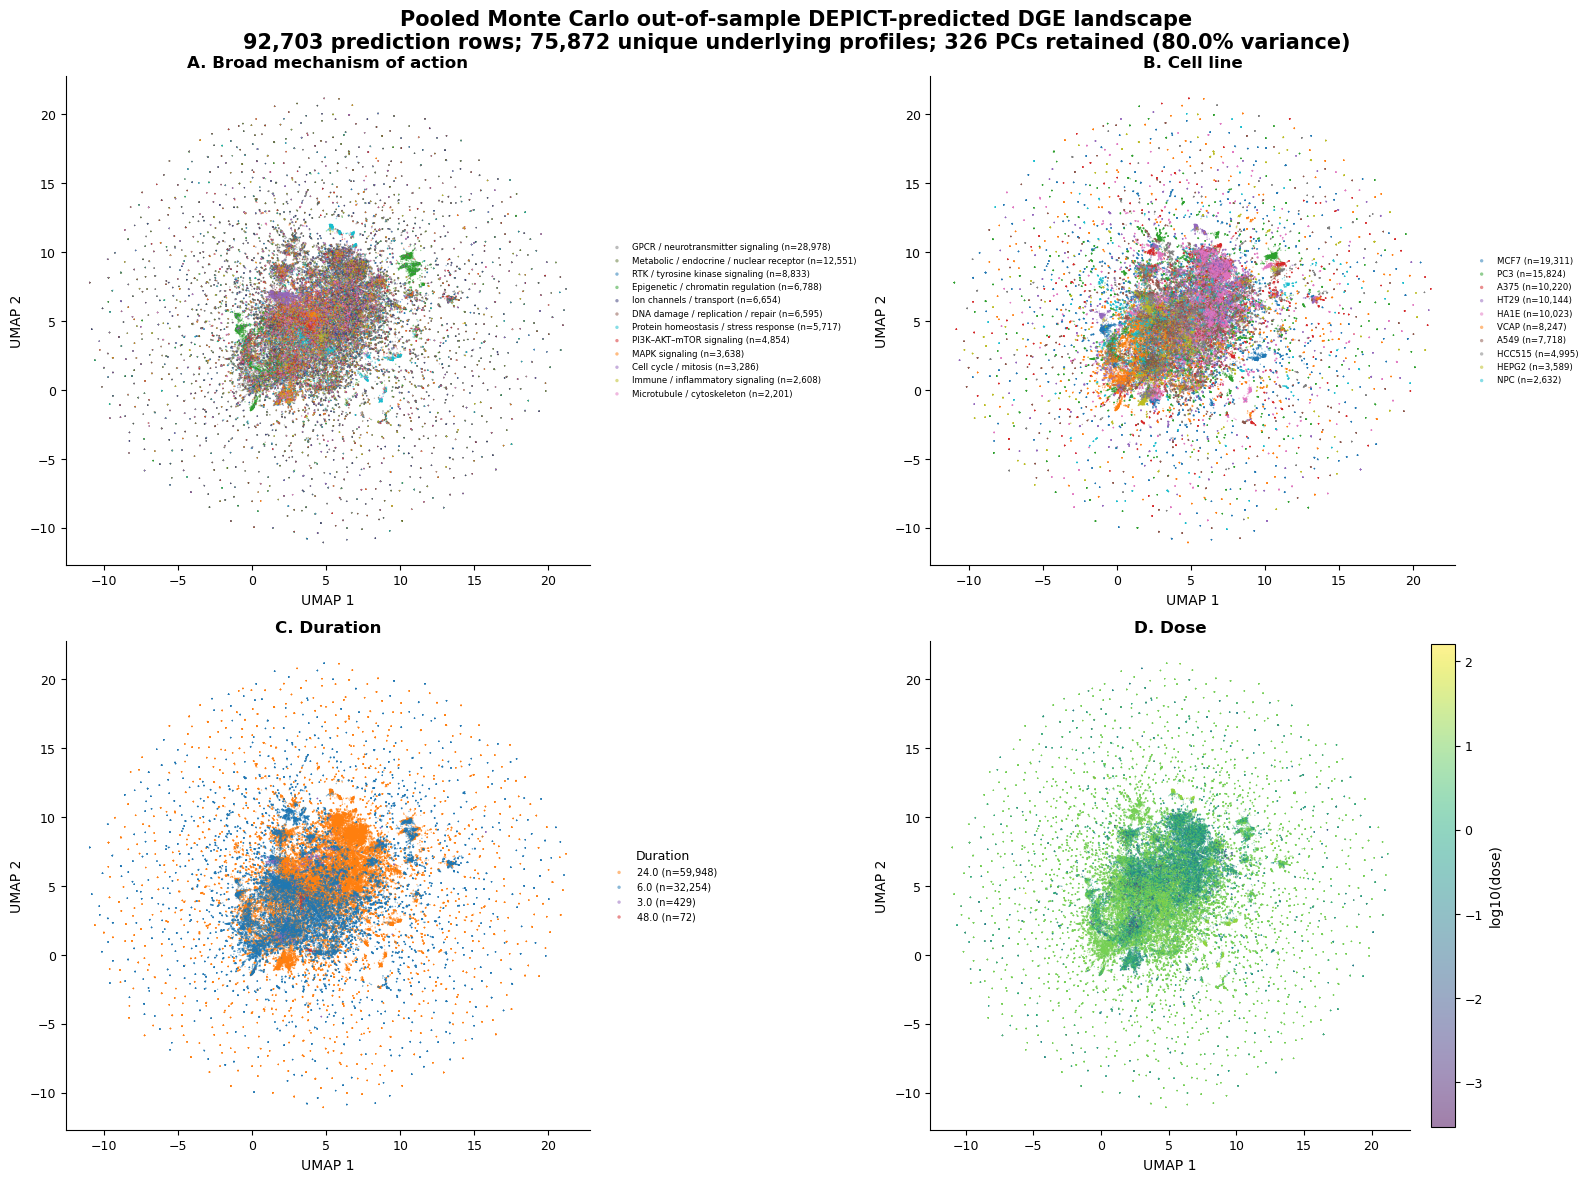

Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DGEStructureAnalysis/Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE/PanelsAtoD_PooledMonteCarlo_GlobalPredictedDGE.pdf


In [14]:

# 13. Main pooled biological figure: Panels A-D
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

categorical_plot(
    axes[0,0], xy, final_meta["broad_moa"],
    "A. Broad mechanism of action",
    order=MOA_ORDER,
    fixed_colors=MOA_COLOR_MAP,
)

categorical_plot(
    axes[0,1], xy, final_meta["cell_id"],
    "B. Cell line",
    order=GLOBAL_TOP10_CELLS,
    fixed_colors=CELL_COLOR_MAP,
)

duration_plot(
    axes[1,0], xy, final_meta["pert_time"],
    "C. Duration",
)

sc = dose_plot(
    axes[1,1], xy, final_meta["dose"],
    "D. Dose",
)

cbar = fig.colorbar(sc, ax=axes[1,1], fraction=0.046, pad=0.04)
cbar.set_label("log10(dose)")

fig.suptitle(
    "Pooled Monte Carlo out-of-sample DEPICT-predicted DGE landscape\n"
    f"{len(final_meta):,} prediction rows; "
    f"{final_meta['underlying_profile_id'].nunique():,} unique underlying profiles; "
    f"{n_pcs} PCs retained ({achieved_var:.1%} variance)",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

main_pdf = OUT_ROOT / "PanelsAtoD_PooledMonteCarlo_GlobalPredictedDGE.pdf"
fig.savefig(main_pdf, bbox_inches="tight", dpi=300)

plt.show()
plt.close(fig)

print("Saved:", main_pdf)


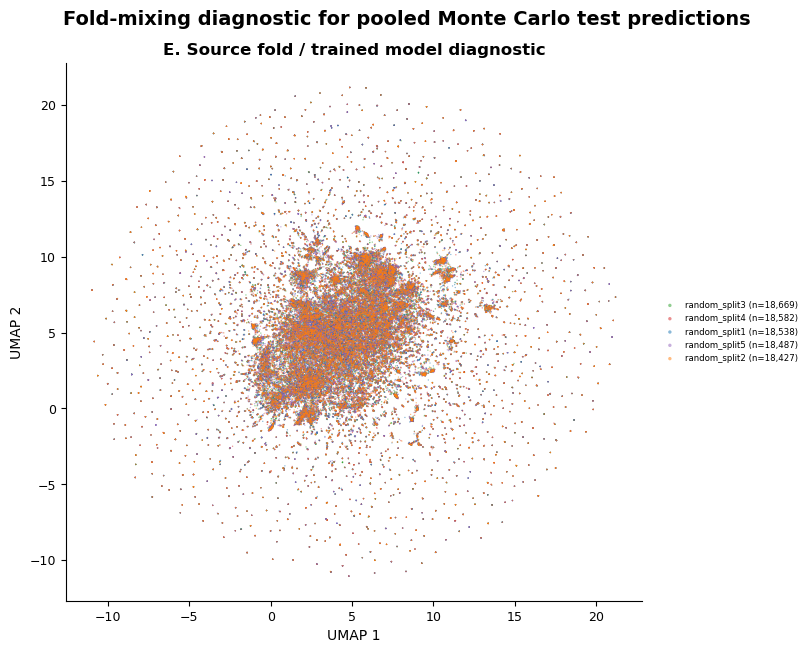

Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DGEStructureAnalysis/Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE/PanelE_SourceFold_Diagnostic.pdf


In [15]:

# 14. Panel E diagnostic: source fold / trained model
fig, ax = plt.subplots(figsize=(8.2, 6.6))

categorical_plot(
    ax, xy, final_meta["source_fold"],
    "E. Source fold / trained model diagnostic",
    order=RANDOM_SPLITS,
    fixed_colors=FOLD_COLOR_MAP,
)

fig.suptitle(
    "Fold-mixing diagnostic for pooled Monte Carlo test predictions",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout()

fold_pdf = OUT_ROOT / "PanelE_SourceFold_Diagnostic.pdf"
fig.savefig(fold_pdf, bbox_inches="tight", dpi=300)

plt.show()
plt.close(fig)

print("Saved:", fold_pdf)



Per-fold kNN mixing:
  source_fold  mean_different_fold_neighbor_fraction  median_different_fold_neighbor_fraction  q25_different_fold_neighbor_fraction  q75_different_fold_neighbor_fraction  n_profiles  expected_random_mixing  mean_minus_random_expectation
random_split1                               0.790954                                      0.8                              0.733333                              0.833333       18538                0.799996                      -0.009042
random_split2                               0.793479                                      0.8                              0.733333                              0.833333       18427                0.799996                      -0.006517
random_split3                               0.796970                                      0.8                              0.733333                              0.866667       18669                0.799996                      -0.003026
random_split4                 

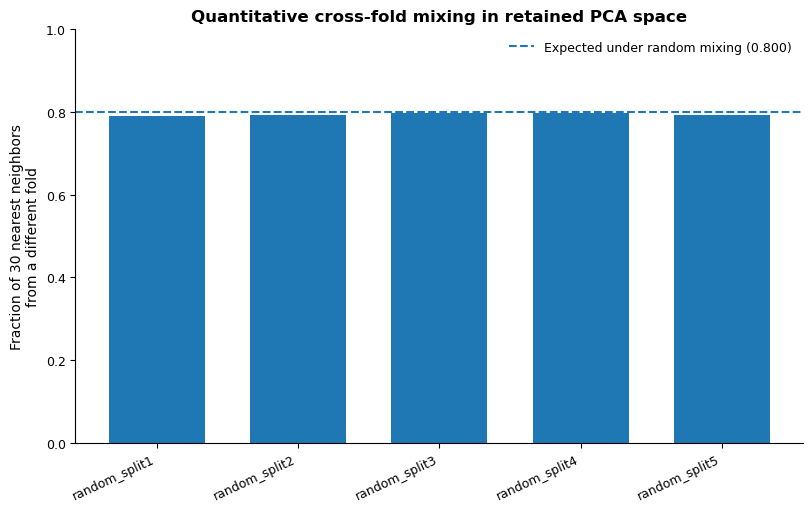

Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DGEStructureAnalysis/Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE/PanelE_kNN_FoldMixing_Quantitative.pdf


In [16]:

# 15. Quantitative kNN fold-mixing diagnostic in retained PCA space
# For each profile, calculate the fraction of its k nearest neighbors
# coming from a DIFFERENT source fold. A higher value means stronger
# cross-fold mixing.

nn = NearestNeighbors(
    n_neighbors=K_MIX + 1,
    metric="cosine",
)
nn.fit(Xp)

neighbor_idx = nn.kneighbors(return_distance=False)[:, 1:]
fold_labels = final_meta["source_fold"].to_numpy()

different_fold_fraction = np.mean(
    fold_labels[neighbor_idx] != fold_labels[:, None],
    axis=1,
)

mixing_df = final_meta[
    ["source_fold", "underlying_profile_id"]
].copy()

mixing_df["different_fold_neighbor_fraction_k30"] = (
    different_fold_fraction
)

# Expected different-fold fraction under random mixing, based only on
# observed fold proportions in the pooled analysis:
# P(neighbor comes from a different fold) = 1 - sum_k p_k^2
fold_proportions = (
    final_meta["source_fold"]
    .value_counts(normalize=True)
    .reindex(RANDOM_SPLITS)
    .fillna(0.0)
)

expected_random_mixing = float(
    1.0 - np.sum(np.square(fold_proportions.to_numpy()))
)

mixing_summary = (
    mixing_df.groupby("source_fold", as_index=False)
    .agg(
        mean_different_fold_neighbor_fraction=(
            "different_fold_neighbor_fraction_k30",
            "mean",
        ),
        median_different_fold_neighbor_fraction=(
            "different_fold_neighbor_fraction_k30",
            "median",
        ),
        q25_different_fold_neighbor_fraction=(
            "different_fold_neighbor_fraction_k30",
            lambda x: x.quantile(0.25),
        ),
        q75_different_fold_neighbor_fraction=(
            "different_fold_neighbor_fraction_k30",
            lambda x: x.quantile(0.75),
        ),
        n_profiles=(
            "different_fold_neighbor_fraction_k30",
            "size",
        ),
    )
)

mixing_summary["expected_random_mixing"] = expected_random_mixing
mixing_summary["mean_minus_random_expectation"] = (
    mixing_summary["mean_different_fold_neighbor_fraction"]
    - expected_random_mixing
)

overall_mixing_summary = pd.DataFrame([{
    "k_neighbors": K_MIX,
    "overall_mean_different_fold_neighbor_fraction": float(
        mixing_df["different_fold_neighbor_fraction_k30"].mean()
    ),
    "overall_median_different_fold_neighbor_fraction": float(
        mixing_df["different_fold_neighbor_fraction_k30"].median()
    ),
    "expected_random_mixing_given_fold_proportions": expected_random_mixing,
    "overall_mean_minus_random_expectation": float(
        mixing_df["different_fold_neighbor_fraction_k30"].mean()
        - expected_random_mixing
    ),
}])

mixing_df.to_parquet(
    OUT_ROOT / "fold_mixing_k30_profile_level.parquet",
    index=False,
)
mixing_summary.to_csv(
    OUT_ROOT / "fold_mixing_k30_summary_by_fold.csv",
    index=False,
)
overall_mixing_summary.to_csv(
    OUT_ROOT / "fold_mixing_k30_summary_overall.csv",
    index=False,
)

print("\nPer-fold kNN mixing:")
print(mixing_summary.to_string(index=False))

print("\nOverall kNN mixing:")
print(overall_mixing_summary.to_string(index=False))

# Plot fold-wise mean mixing with random-mixing expectation.
fig, ax = plt.subplots(figsize=(8.2, 5.2))

x = np.arange(len(mixing_summary))
means = mixing_summary["mean_different_fold_neighbor_fraction"].to_numpy()

ax.bar(
    x,
    means,
    width=0.68,
)

ax.axhline(
    expected_random_mixing,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Expected under random mixing "
        f"({expected_random_mixing:.3f})"
    ),
)

ax.set_xticks(x)
ax.set_xticklabels(
    mixing_summary["source_fold"],
    rotation=25,
    ha="right",
)
ax.set_ylim(0, 1)
ax.set_ylabel(
    f"Fraction of {K_MIX} nearest neighbors\nfrom a different fold"
)
ax.set_title(
    "Quantitative cross-fold mixing in retained PCA space",
    fontweight="bold",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()

mix_pdf = OUT_ROOT / "PanelE_kNN_FoldMixing_Quantitative.pdf"
fig.savefig(
    mix_pdf,
    bbox_inches="tight",
    dpi=300,
)

plt.show()
plt.close(fig)

print("Saved:", mix_pdf)



## Interpretation guardrails

- This is a pooled Monte Carlo test-prediction landscape, not a unique-profile census.
- Repeated underlying profiles across folds are intentionally retained because they may represent predictions from different trained models.
- Repetition is explicitly tracked in output tables.
- Robustness is not established by pooling alone; the five fold-specific Module 2A plots remain the replication evidence.
- The source-fold diagnostic is mandatory:
  - strong cross-fold mixing supports pooled biological interpretation;
  - fold-specific territories would indicate model-specific batch structure.
- No fold-specific normalization or harmonization is applied.



### Interpreting the kNN fold-mixing statistic
The expected different-fold-neighbor fraction under random mixing is computed from the observed fold proportions as `1 - sum(p_k^2)`. The observed kNN mixing should be compared with this expectation rather than interpreted in isolation.
